<a href="https://colab.research.google.com/github/asr7code/HouseRentPrediction_LinReg/blob/main/AIML(26)_LinearReg_HRent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd

# Load Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iamsouravbanerjee/house-rent-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'house-rent-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/house-rent-prediction-dataset


In [ ]:
df = pd.read_csv("/kaggle/input/house-rent-prediction-dataset/House_Rent_Dataset.csv")

In [ ]:
df

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


## Inspect

In [ ]:
print(df.shape)
print(df.columns)
print(df.describe())
print(df.info())

(4746, 12)
Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')
               BHK          Rent         Size     Bathroom
count  4746.000000  4.746000e+03  4746.000000  4746.000000
mean      2.083860  3.499345e+04   967.490729     1.965866
std       0.832256  7.810641e+04   634.202328     0.884532
min       1.000000  1.200000e+03    10.000000     1.000000
25%       2.000000  1.000000e+04   550.000000     1.000000
50%       2.000000  1.600000e+04   850.000000     2.000000
75%       3.000000  3.300000e+04  1200.000000     2.000000
max       6.000000  3.500000e+06  8000.000000    10.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK  

# Preprocessing

### Drop Non Important Columns

In [ ]:
df = df.drop(["Posted On", "Area Locality"], axis=1)

In [ ]:
df = df.drop("Floor", axis=1)

### Visualization

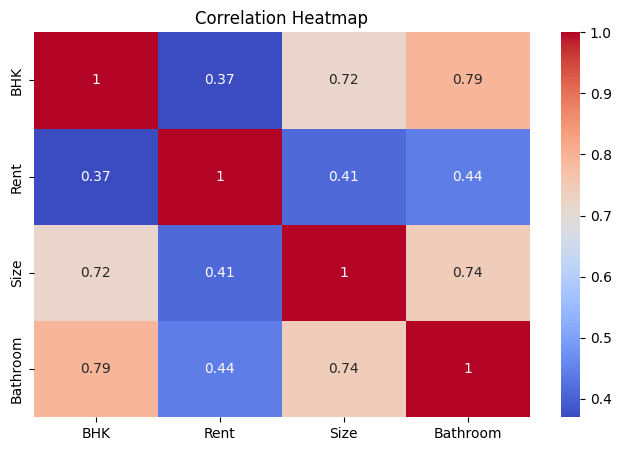

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

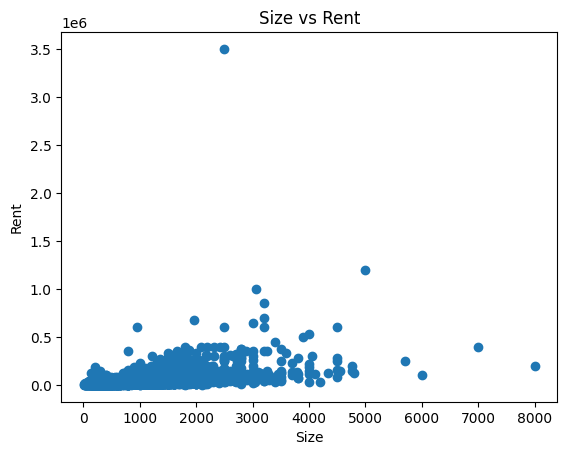

In [ ]:
plt.scatter(df["Size"], df["Rent"])
plt.xlabel("Size")
plt.ylabel("Rent")
plt.title("Size vs Rent")
plt.show()

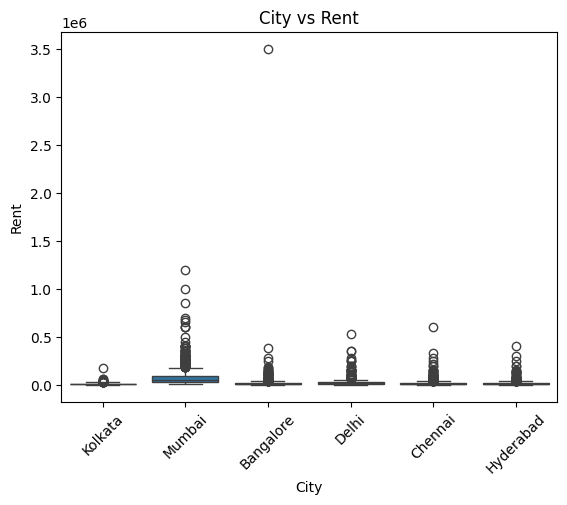

In [ ]:
sns.boxplot(x="City", y="Rent", data=df)
plt.xticks(rotation=45)
plt.title("City vs Rent")
plt.show()

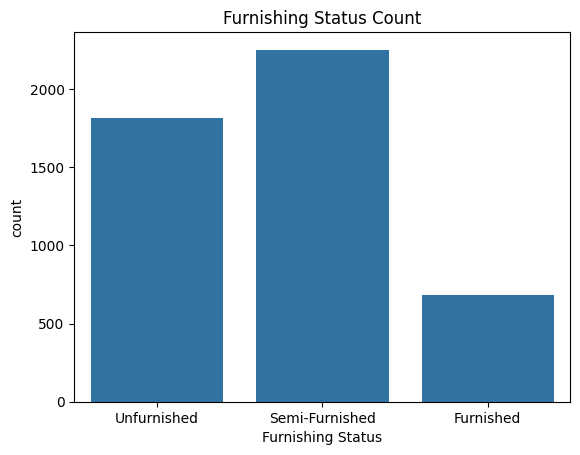

In [ ]:
sns.countplot(x="Furnishing Status", data=df)
plt.title("Furnishing Status Count")
plt.show()

In [ ]:
# Outlier remove
df = df[df["Rent"] < 200000]

## Initialization

In [ ]:
X = df.drop("Rent", axis=1)
y = df["Rent"]

## Encoding

In [ ]:
X = pd.get_dummies(X, drop_first=True)

## Test Train Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((3705, 16), (927, 16))

# Model Import and Fitting

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

## Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 11693.99272803136
RMSE: 18451.372154641977
R2 Score: 0.6508390180073089


In [ ]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coeff_df.sort_values(by="Coefficient", ascending=False).head(10)

,Coefficient
City_Mumbai,32545.461146
Bathroom,7826.476712
City_Delhi,5375.494199
BHK,4050.909005
Tenant Preferred_Bachelors/Family,2137.321350
Point of Contact_Contact Builder,1587.330065
Size,14.348959
Area Type_Carpet Area,-456.302487
City_Kolkata,-1931.541094
City_Chennai,-1959.861616


# Saving Model

In [ ]:
import pickle

with open("rent_model.pkl", "wb") as f:
    pickle.dump(model, f)